In [1]:
print("Hello World")

Hello World


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv(r"D:\Downloads\placement.csv")

In [4]:
df.sample(10)

,cgpa,package
195,6.93,2.46
28,5.94,2.24
73,8.44,4.03
190,6.19,2.69
34,7.34,3.42
19,7.48,2.83
74,6.85,3.44
80,7.63,3.44
128,7.93,3.34
117,7.12,2.99


Text(0, 0.5, 'Package in lpa')

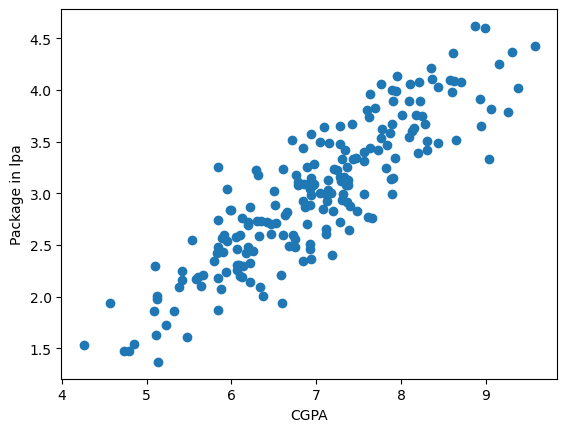

In [5]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package in lpa')

In [6]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

LinearRegression()

In [11]:
X_train

,cgpa
137,7.14
163,8.93
111,5.42
123,5.10
109,7.77
...,...
43,7.66
22,6.14
72,7.78
15,7.25


In [12]:
X_train


,cgpa
137,7.14
163,8.93
111,5.42
123,5.10
109,7.77
...,...
43,7.66
22,6.14
72,7.78
15,7.25


In [13]:
y_train

137    3.13
163    3.91
111    2.25
123    2.30
109    4.06
       ... 
43     2.76
22     2.30
72     3.62
15     3.23
168    3.52
Name: package, Length: 160, dtype: float64

In [14]:
df.iloc[163]

cgpa       8.93
package    3.91
Name: 163, dtype: float64

In [15]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [16]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [17]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

In [18]:
# X_test.iloc[0].values.reshape(1,1) is 2d array which needs(2d data) in ml model.

In [19]:
lr.predict(X_test.iloc[[2]])   # above warning solution.

# Warning aa raha hai because:

# Model was trained using a DataFrame with column names

# But prediction time pe tum NumPy array bhej rahe ho (values.reshape(1,1))

# So sklearn bol raha hai:

# "Training me feature name tha (like CGPA), but prediction me name missing hai."

# ❌ Your current code
# lr.predict(X_test.iloc[0].values.reshape(1,1))
# This converts data into NumPy array → feature name lost.

# ✅ Best Solution (Recommended)
# Use double brackets:
# lr.predict(X_test.iloc[[0]])

# 🔥 Why this removes warning?
# Because:

# iloc[[0]] returns a DataFrame

# DataFrame keeps column name (CGPA)

# Model happy ho jata hai 😄

# ⚠️ Avoid this
# .values.reshape(1,1)
# unless you intentionally want NumPy arrays.
# For pandas + sklearn workflows, DataFrame approach is cleaner and professional.

array([2.38464568])

Text(0, 0.5, 'Package(in lpa)')

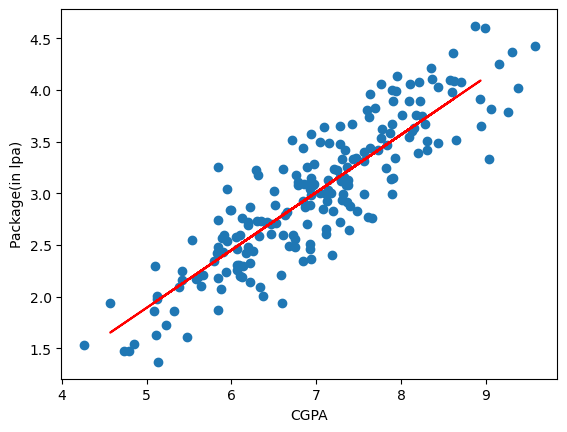

In [20]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_test,lr.predict(X_test),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [21]:
m = lr.coef_
b = lr.intercept_

In [22]:
def predict(x):

    y = m*x + b
    return print("the package is", y, "lpa")

In [23]:
print(predict(7.14))

the package is [3.08766517] lpa
None


In [24]:
print(predict(7))   # why give none ? 

the package is [3.00955189] lpa
None


In [25]:
lr.predict(pd.DataFrame([[100]], columns = ['cgpa']))   # 100 not present in cgpa data, use this method.

array([54.89908542])

In [26]:
predict(100) # by using the values of m and b we directly calculate the package,  
             # whereas we have the restriction to pass "dataframe" with "feature name" in predict method. 

the package is [54.89908542] lpa


Text(0, 0.5, 'Package(in lpa)')

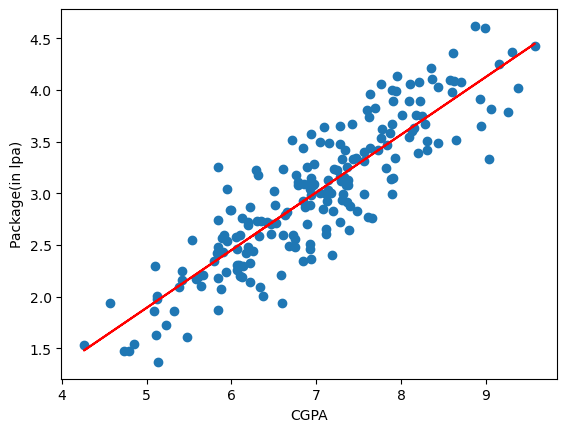

In [27]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X, lr.predict(X), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [28]:
y_train

137    3.13
163    3.91
111    2.25
123    2.30
109    4.06
       ... 
43     2.76
22     2.30
72     3.62
15     3.23
168    3.52
Name: package, Length: 160, dtype: float64

# BY Codebasics

In [29]:
import pandas as pd

In [30]:
df = pd.read_csv(r"D:\Downloads\ML_Regression_LinearRegression_resources\home_prices.csv")
df

,area_sqr_ft,price_lakhs
0,656,39.0
1,1260,83.2
2,1057,86.6
3,1259,59.0
4,1800,140.0
5,1325,80.1
6,1085,116.0
7,1110,45.0
8,1700,100.0
9,960,89.0


In [31]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['area_sqr_ft']], df["price_lakhs"])  # we can also write---> model.fit(df[['area_sqr_ft']], df[["price_lakhs"]]),
                                                   # but this is not compulsory.

LinearRegression()

In [32]:
model.predict([[1500],[700]])

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([95.56913434, 54.22372995])

In [33]:
model.predict(df[['area_sqr_ft']].iloc[0:2])  # above warning solution.

array([51.9497327 , 83.16551302])

In [34]:
model.predict(df[['area_sqr_ft']].iloc[[0]]) # if we remove one [] from iloc ---> model.predict(df[['area_sqr_ft']].iloc[0]) we will get error because
                                             # "df[['area_sqr_ft']].iloc[0]" we pass now become a series, see below code:

array([51.9497327])

In [35]:
print(type(df[['area_sqr_ft']].iloc[[0]]))  # model expect the dataframe as input....> predict(dataframe)
type(df[['area_sqr_ft']].iloc[0])   

<class 'pandas.core.frame.DataFrame'>


pandas.core.series.Series

In [36]:
model.predict(pd.DataFrame([[1500],[700]], columns=['area_sqr_ft'])) # 1500 is not present in dataframe, use this method to avoid warning.    

array([95.56913434, 54.22372995])

In [37]:
lr.predict([[100]], columns = ['cgpa'])  # you gave here 'columns' other than dataframe.  

TypeError: LinearModel.predict() got an unexpected keyword argument 'columns'

In [ ]:
lr.predict(pd.DataFrame([[100],[700]], columns = ['cgpa'])) # now you pass a dataframe, see below code:

In [ ]:
pd.DataFrame([[100],[700]], columns = ['cgpa']) # dataframe

In [ ]:
pd.DataFrame([[100,700]] , columns = ['cgpa', 'iq'])

# Multiple Linear Regression by Codebasics.

In [38]:
df = pd.read_csv(r"D:\Downloads\ML_Regression_MultipleLinearRegression_resources\home_prices.csv")
df

,area_sqr_ft,price_lakhs,bedrooms
0,656,39.0,2
1,1260,83.2,2
2,1057,86.6,3
3,1259,59.0,2
4,1800,140.0,3
5,1325,80.1,2
6,1085,116.0,3
7,1110,45.0,2
8,1700,100.0,3
9,960,89.0,2


In [39]:
X = df[["area_sqr_ft", "bedrooms"]]
y = df["price_lakhs"] 

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [43]:
model.predict([[1260,2]])

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([69.38267958])

In [45]:
model.predict(X.iloc[[1]])

array([69.38267958])

In [48]:
model.predict(pd.DataFrame([[656],[2]], columns = "area_sqr_ft", "bedrooms"))

SyntaxError: positional argument follows keyword argument (168772889.py, line 1)

In [53]:
# above reson:

# Mistake: columns argument

# You passed:

# columns = "area_sqr_ft", "bedrooms"

# After a keyword argument (columns = ...), you cannot add another positional argument. That's why Python says:

# "SyntaxError: positional argument follows keyword argument"

# Also: Data shape is wrong

# If your model was trained on two features:

# area_sqr_ft
# bedrooms

# then one house should be represented as:

# area_sqr_ft	bedrooms
# 656	2

# So you need one row, two columns, not two rows and one column.

# ✅ Correct code
# model.predict(
#     pd.DataFrame(
#         [[656, 2]],
#         columns=["area_sqr_ft", "bedrooms"]
#     )
# )
# Shape:
# (1, 2)

# Meaning:

# 1 sample (one house)
# 2 features (area_sqr_ft, bedrooms)
# Quick intuition
# [[656], [2]]

# means:

# ?
# 656
# 2

# ➡️ 2 samples, 1 feature

# while

# [[656, 2]]

# means:

# area_sqr_ft	bedrooms
# 656	2

# ➡️ 1 sample, 2 features (what you want).

In [49]:
model.predict(pd.DataFrame([[656, 2]],columns=["area_sqr_ft", "bedrooms"]))

array([53.25831232])

In [50]:
model.predict(pd.DataFrame([[100, 1]],columns=["area_sqr_ft", "bedrooms"]))

array([7.37539137])

In [55]:
# warning solution by codebasics: we make a dataframe named "test"

test = pd.DataFrame([
    {'area_sqr_ft': 1500, "bedrooms": 3},
    {'area_sqr_ft': 2000, "bedrooms": 2}
])

In [57]:
model.predict(test)  # we pass above dataframe in predict, beacuse predict function expect dataframe as argument.

array([106.82967328,  89.13769907])